### **Submission rules**:
1. The completed assignment should be prepared as s a Jupyter Notebook (.ipynb file). Please make a copy of this notebook for your team. Make sure you opened it via UCU email address. Submit the Jupyter Notebook (.ipynb file) to **lms**.
2. Please execute all the cells before submission; make sure there are no errors, everything has been generated, and all numerical answers calculated.
3. There should be only one submission per team. However, don't forget to choose a person from your team who would submit the task, and make sure that the names of all team members are listed in the notebook. Teammates not mentioned in the notebook will not be graded for this lab.
4. You also need to provide a work breakdown structure estimating the efforts of each team member. Please provide it at the top of your notebook. If you do not provide the work breakdown, the points will be reducted from your work.
5. The final deadline is specified on LMS.

**IMPORTANT**: If you submit your assignment after this time and date, it will not be graded.

# Image compression with SVD

The singular value decomposition of a matrix A is the factorization of A into the
product of three matrices:
\begin{align}
 A = UDV^T,
 \end{align}
where the columns of U and V are orthonormal and
the matrix D is diagonal with positive real entries. The SVD is useful in many tasks. First, in many applications, the data matrix A is close to a
matrix of low rank and it is useful to find a low rank matrix which is a good approximation
to the data matrix. You will show that from the singular value decomposition of A, we can get the matrix B of rank k which best approximates A; in fact, we can do this for every
k. Also, singular value decomposition is defined for all matrices (rectangular or square) unlike spectral decomposition, although the latter one is used more commonly in Linear Algebra.

Considering that any image can be represented as a rectangular matrix, you can find the best rank k approximation of this image using SVD. The idea is that by significantly reducing the storage space, you can still preserve a very good quality of the image

In [2]:
import time
# from google.colab.patches import cv2_imshow
import cv2 as cv
import numpy as np
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widget
import matplotlib.pyplot as plt
import numpy as np

## SVD implementation (0.5)

Implement a function to compute SVD of the matrix.

Do not use the built-in functions; instead, compare your solution with the built-in one.

*Hint:* one of the simpliest methods for finding eigenvalues and eigenvectors of the matrix is [Power Iteration](https://en.wikipedia.org/wiki/Power_iteration). Hovewer, you may try some advanced methods :)

In [3]:
def power_iteration(A, num_iterations=100):
    """Finds the dominant right singular vector v of matrix A."""
    n_cols = A.shape[1]
    
    v = np.random.rand(n_cols)
    v = v / np.linalg.norm(v)
    
    for _ in range(num_iterations):
        v_new = A.T @ (A @ v)
        v = v_new / np.linalg.norm(v_new)
        
    return v

def compute_svd(A, k=None, iterations=100, threshold=1e-10):
    """
    Computes the top k singular values and vectors of matrix A.
    Returns U, Sigma (as a list), and V^T.
    """
    A_deflated = A.copy().astype(float)
    n_rows, n_cols = A.shape
    
    if k is None:
        k = min(n_rows, n_cols)
        
    u_vectors = []
    singular_values = []
    v_vectors = []
    
    for i in range(k):
        v = power_iteration(A_deflated, iterations)
        
        u_unnormalized = A_deflated @ v
        sigma = np.linalg.norm(u_unnormalized)
        
        if sigma < threshold:
            break
            
        u = u_unnormalized / sigma
        
        u_vectors.append(u)
        singular_values.append(sigma)
        v_vectors.append(v)
        
        u_col = u.reshape(-1, 1)
        v_row = v.reshape(1, -1)
        
        A_deflated = A_deflated - (sigma * (u_col @ v_row))
        
    U = np.array(u_vectors).T
    V_T = np.array(v_vectors)
    Sigma = np.array(singular_values)
    
    return U, Sigma, V_T

### Comparison with SVD solver from numpy

In [4]:
np.random.seed(42)
A = np.random.rand(80, 120) * 10 

print("--- Testing Custom SVD ---")
start_time = time.time()
U_custom, S_custom, VT_custom = compute_svd(A, iterations=200)
custom_time = time.time() - start_time
print(f"Time taken: {custom_time:.5f} seconds")
print(f"Singular Values: {np.round(S_custom, 4)}\n")

print("--- Testing NumPy SVD ---")
start_time = time.time()
U_np, S_np, VT_np = np.linalg.svd(A, full_matrices=False)
np_time = time.time() - start_time
print(f"Time taken: {np_time:.5f} seconds")
print(f"Singular Values: {np.round(S_np, 4)}\n")

print("--- Comparison ---")
difference = np.abs(S_custom - S_np)
print(f"Maximum difference in singular values: {np.max(difference):.2e}")

--- Testing Custom SVD ---
Time taken: 0.46637 seconds
Singular Values: [486.0611  53.6588  52.9851  52.4011  51.7597  51.3724  49.5787  48.4864
  48.3565  48.0263  45.9014  45.5213  44.3219  44.0941  43.3113  42.8374
  41.2577  41.0288  40.033   40.3123  39.1262  38.9349  37.8166  37.2244
  35.9524  35.7198  35.2583  34.1822  33.9244  33.5567  33.2623  32.3498
  31.6162  30.9883  30.7878  30.3941  29.4463  28.9948  28.4484  28.256
  27.7373  27.2526  26.517   25.416   25.0858  24.7749  24.3416  24.138
  23.2282  22.4613  22.173   22.0915  21.7988  20.9447  20.3534  19.9074
  19.6192  19.2998  18.8524  18.3277  17.4027  16.9154  16.4987  16.2772
  15.4617  14.7278  13.7631  13.5083  12.6478  12.2893  11.8909  11.5402
  10.5238  10.289    9.7776   9.2511   8.67     8.124    6.89     6.8514]

--- Testing NumPy SVD ---
Time taken: 0.01761 seconds
Singular Values: [486.0611  53.6588  52.9851  52.4011  51.7601  51.3721  49.5787  48.5439
  48.3373  47.9876  45.9016  45.5211  44.3221  44.0939

Explain in detailes the chosen method for finding SVD.


---


### General Singular Value Decomposition via Power Iteration

**Given:** General real matrix $A \in \mathbb{R}^{m \times n}$.  
**Goal:** Compute SVD components $U, \Sigma, V^T$ such that $A = U \Sigma V^T$.

For each singular component $i = 1, 2, \dots, k$:

#### Step 1: Power Iteration (Right Singular Vector $v_i$)
Initialize a random vector $v^{(0)}$ where $\|v^{(0)}\| = 1$.  
Iterate until convergence by applying $A^T A$ implicitly to preserve precision:
$$v^{(m+1)} = \frac{A^T (A v^{(m)})}{\|A^T (A v^{(m)})\|}$$
Resulting right singular vector: 
$$v_i = v^{(\infty)}$$

#### Step 2: Projection (Singular Value $\sigma_i$)
From SVD definition $A = U \Sigma V^T$, right-multiplying by $V$ yields $AV = U\Sigma$. Equating the $i$-th column gives the fundamental relation:
$$A v_i = \sigma_i u_i$$
Since $u_i$ is a unit vector ($\|u_i\| = 1$), taking the norm of both sides isolates $\sigma_i$.

$$w_i = A v_i$$
$$\sigma_i = \|w_i\|$$
*(Stop condition: Break if $\sigma_i < \epsilon$, indicating the matrix is rank-deficient)*

#### Step 3: Normalization (Left Singular Vector $u_i$)
Rearranging the fundamental relation $A v_i = \sigma_i u_i$ directly solves for the direction $u_i$.

$$u_i = \frac{w_i}{\sigma_i}$$

#### Step 4: General Deflation
The matrix SVD can be rewritten as a sum of independent rank-1 outer products:
$$A = \sum_{j=1}^k \sigma_j u_j v_j^T$$
Subtracting the largest known component ($\sigma_i u_i v_i^T$) removes it from the sum, making the next component ($\sigma_{i+1}$) the new dominant value.

$$A \leftarrow A - \sigma_i u_i v_i^T$$

Repeat Steps 1-4 for the newly deflated matrix $A$.



---



Explain why finding the roots of characteristic polynomial for finding eigenvalues is not always the best choice.

---

### Why the Characteristic Polynomial is a Poor Choice for Eigenvalues

Finding eigenvalues by solving$$p(\lambda)=\det(A-\lambda I)=0$$is mathematically correct, but it is usually a bad numerical method. The problem is that we first turn the matrix into polynomial coefficients, and then try to recover the roots from those coefficients. Both steps can lose a lot of accuracy.
#### 1. Catastrophic cancellation in coefficients.
When we expand the determinant, the coefficients are obtained from many products and sums of matrix entries. Some of these terms can be very large and can nearly cancel each other. Because of floating-point rounding, the final coefficients of the polynomial may contain noticeable errors, even if the original matrix is not problematic.So instead of solving the original eigenvalue problem, we solve a new polynomial root-finding problem whose coefficients may already be inaccurate.
#### Wilkinson's example:
$$p(\lambda)=\prod_{k=1}^{20}(\lambda-k)$$has roots$$1,2,\ldots,20.$$These roots look simple and well-separated. However, a tiny perturbation in one coefficient can move some roots by a large amount, and some roots can even become complex. This shows that polynomial roots can be extremely sensitive to very small coefficient errors.
#### 2. Ill-conditioning near clustered eigenvalues.  
For a simple root $\lambda_0$, the sensitivity of the root depends roughly on$$\frac{1}{|p'(\lambda_0)|}.$$If two eigenvalues are close to each other, then the corresponding roots of the characteristic polynomial are also close. In this case, $p'(\lambda_0)$ can become very small, so even tiny errors in the polynomial coefficients can cause large errors in the computed roots.This is especially bad because the matrix eigenvalue problem itself can still be well-behaved, while the polynomial version becomes numerically unstable.**Small example:**  $$A=\begin{pmatrix}2 & \varepsilon \\\varepsilon & 2+\varepsilon\end{pmatrix},\qquad\varepsilon=10^{-8}.$$This matrix is symmetric, so its eigenvalues are well-defined and numerically stable as a matrix problem. But the two eigenvalues are separated only by a value of order $\varepsilon$. If we compute them by first forming the characteristic polynomial, rounding errors in the coefficients can destroy many significant digits in this small difference.So the roots may still look close to $2$, but their separation can be very inaccurate.
#### 3. Loss of structure.
The original matrix may have useful structure: it can be sparse, symmetric, banded, triangular, etc. Matrix algorithms can use this structure directly.But after expanding$$\det(A-\lambda I),$$we only have a polynomial. The sparsity or symmetry of the matrix is no longer useful. This makes the method less efficient and less stable.
#### 4. No real computational advantage.
Computing the characteristic polynomial is not cheaper in practice. It can cost about as much as direct eigenvalue algorithms, but then we still need to solve the polynomial root-finding problem afterward.Algorithms like QR iteration, Jacobi, Lanczos, or Arnoldi work directly with the matrix. They are usually more stable and can exploit the structure of the matrix.
#### Conclusion:
The characteristic polynomial is useful for theory and small symbolic examples, but it is usually not the best way to compute eigenvalues numerically. It introduces errors in the coefficients, makes root sensitivity worse, and loses useful matrix structure. In practice, eigenvalues are computed from the matrix directly, not by explicitly forming and solving the characteristic polynomial.

---


## SVD of symmetric matrices (0.5 pts)

Here you have a symmetric matrix A. Compute a full SVD of this matrix.

In [12]:
import numpy as np

def power_iteration(A, num_simulations=100):
    n = A.shape[0]
    v = np.random.rand(n)
    v = v / np.linalg.norm(v)

    for _ in range(num_simulations):
        v_new = A @ (A @ v)
        v_new_norm = np.linalg.norm(v_new)
        if v_new_norm == 0: break
        v = v_new / v_new_norm

    sigma = np.linalg.norm(A @ v)
    u = (A @ v) / sigma if sigma != 0 else v
    return u, sigma, v

def symmetric_svd(A, k=None):
    n = A.shape[0]
    if k is None: k = n

    A_curr = A.astype(float).copy()
    U, S, V = [], [], []

    for _ in range(k):
        u, s, v = power_iteration(A_curr)
        U.append(u)
        S.append(s)
        V.append(v)
        A_curr -= s * np.outer(u, v)

    return np.array(U).T, np.array(S), np.array(V)

A_sym = np.array([[1, 2, 3, 4], [2, 7, 4, 5], [3, 4, 3, 8], [4, 5, 8, 3]])
U, S, Vt = symmetric_svd(A_sym)
print(f"Singular values: {S}")

Singular values: [17.33847234  5.15839249  2.79573697  0.97581683]


#### 1. Explain what matrices did you get as a result. What can you say about singular values of this matrix (about its eigenvalues)?

The SVD of a symmetric matrix $A$ produces $A = U \Sigma V^T$.

*   **U (Left Singular Vectors)**: Orthonormal columns that represent the principal axes of the data.
*   **$\Sigma$ (Singular Values)**: A diagonal matrix where $\sigma_i$ are the singular values.
*   **$V^T$ (Right Singular Vectors)**: Orthonormal rows for symmetric matrices, $V$ is related to $U$.

**Relation to Eigenvalues:**
For a symmetric matrix, the singular values $\sigma_i$ are the absolute values of the eigenvalues $\lambda_i$:
$$\sigma_i = |\lambda_i|$$
The values $[17.33, 5.15, 2.79, 0.97]$ are the magnitudes of the matrix's eigenvalues.

---

#### 2. How SVD relates to matrices $Q, D, Q^T$ in spectral decomposition? Are they identical?

Spectral decomposition is defined as $A = Q \Lambda Q^T$, where $\Lambda$ contains eigenvalues $\lambda_i$. SVD is $A = U \Sigma V^T$.

*   **Are they identical?** No, not always. They are identical only if $A$ is a **positive semi-definite** symmetric matrix ($\lambda_i \ge 0$ for all $i$).
*   **The Difference:**
    *   In **Spectral Decomposition**, $D$ can contain negative values ($\lambda_i < 0$).
    *   In **SVD**, $\Sigma$ must contain only non-negative values ($\sigma_i \ge 0$).
*   **Conclusion:** If the symmetric matrix has any negative eigenvalues, $D \neq \Sigma$ because SVD will use the absolute value $|\lambda_i|$ and adjust the sign in the $U$ or $V$ matrices.

In [13]:
import numpy as np

A = np.array([[1, 2, 3, 4],
              [2, 7, 4, 5],
              [3, 4, 3, 8],
              [4, 5, 8, 3]])

eigenvalues = np.linalg.eigvals(A)
U, S, Vt = np.linalg.svd(A)

print(f"Eigenvalues: {eigenvalues}")
print(f"Singular values: {S}")
print(f"Absolute Eigenvalues: {np.abs(eigenvalues)}")

Eigenvalues: [17.33847234  2.79573697 -0.97581683 -5.15839249]
Singular values: [17.33847234  5.15839249  2.79573697  0.97581683]
Absolute Eigenvalues: [17.33847234  2.79573697  0.97581683  5.15839249]


#### 1. How SVD relates to matrices $Q, D, Q^T$ in spectral decomposition? Are they identical?

For the symmetric matrix $A$, spectral decomposition is $A = Q D Q^T$ and SVD is $A = U \Sigma V^T$.

*   **Relationship**: The singular values $\sigma_i$ in $\Sigma$ are the absolute values of the eigenvalues $\lambda_i$ in $D$: $\sigma_i = |\lambda_i|$.
*   **Are they identical?**: No, they are not identical for this matrix.
    *   **Reason**: As you see, the eigenvalues include negative numbers: $-0.9758$ and $-5.1584$.
    *   **Difference**: In spectral decomposition, $D$ contains these negative values, while in SVD, $\Sigma$ contains only positive magnitudes: $0.9758$ and $5.1584$.

---

#### 2. Can you say that SVD of symmetric matrices always corresponds to its spectral decomposition?

*   **General Rule**: No, SVD does not always correspond to spectral decomposition for all symmetric matrices.
*   **Condition**: They are identical if and only if the symmetric matrix is **positive semi-definite** ($A \succeq 0$).
    *   This means all eigenvalues must be non-negative: $\lambda_i \ge 0$.
*   **Identical Cases**: It is possible to find such matrices; any symmetric matrix where all eigenvalues are $\ge 0$ (e.g., $A = M^T M$) will have identical SVD and spectral decomposition because $\lambda_i = |\lambda_i| = \sigma_i$.

## Image compression using SVD (1 pts)

Upload the picture of a dog.

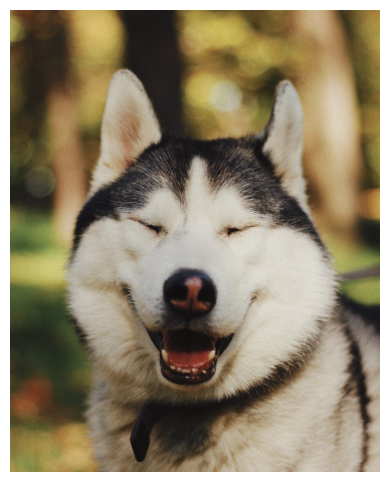

In [6]:
path = 'happy-dog.jpg'
image = cv.imread(path)

image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.axis('off')
plt.show()

image = image.astype('float32')

Complete the below function for finding a reduced SVD of a given matrix. (You may use the functions for finding eigenvalues of the matrix). Highlight the key differences between SVD and the reduced version of it.

In [7]:
def reduced_svd(A):
    '''
    Input: any matrix A
    Returns: tuple of matrix U, array of singular values and matrix V.T
    '''
    ATA = A.T @ A

    eigenvalues, V = np.linalg.eigh(ATA)   # V is matrix which columns correspond to eigenvectors

    sorted_indices = np.argsort(eigenvalues)[::-1] # eigh returns eigenvalues in increasing order, but SVD requires them in decreasing order
    eigenvalues = eigenvalues[sorted_indices]
    V = V[:, sorted_indices]
    
    positive_indices = eigenvalues > 1e-10   # remove mistakes
    eigenvalues = eigenvalues[positive_indices]
    V = V[:, positive_indices]
    
    singular_values = np.sqrt(eigenvalues)
    
    U = (A @ V) / singular_values   # U = A * V / Sigma
    
    return U, singular_values, V.T

The reduced $SVD$ basically chops off all the unimportant data: if a matrix $A$ is of rank $r$, it has only $r$ positive singular values. Other are zeros.
Thus, the reduced $SVD$ gets rid of those zero values $\sigma_i$ and corresponding left and right singular vectors that results in $m \times r$ matrix $U$,
$r \times r$ matrix $\Sigma$ and $r \times n$ matrix $V^T$.

Inspite of that, the reduced $SVD$ still returns us the matrix $A$!

Complete the function below. It should output the k-rank approximation of the given image using previously written SVD function. Use the slider to see how the image quality changes as we increase/decrease k.

For simplification, you can convert your image to a grayscale. However, it will be appreciated if you work with RGB channels (it is possible that you'll need to modify the method below a little).

In [8]:
@interact(k=widget.IntSlider(min=1, max=np.linalg.matrix_rank(image[:, :, 0]), value=100), image=fixed(image))
def k_rank_compressed_image(k, image):
    channels = cv.split(image)   # split on 3 channels by colors
    compressed_channels = []
    
    for channel in channels:
        U, S, VT = reduced_svd(channel)
        
        channel_k = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]   # rank k
        compressed_channels.append(channel_k)
        
    approximated = cv.merge(compressed_channels)   # merge all colors
    
    approximated_disp = np.clip(approximated, 0, 255).astype(np.uint8)   # remove mistakes
    
    approximated_disp = cv.cvtColor(approximated_disp, cv.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(approximated_disp)
    plt.title(f"Compressed Image (rank k = {k})")
    plt.axis('off')
    plt.show()

interactive(children=(IntSlider(value=100, description='k', max=720, min=1), Output()), _dom_classes=('widget-…

In general, compressing the image to 60-80% percent of its original size  lowers its quality but human eye won't be even able to notice it. Therefore, we can win in storage while keeping almost the same image quality. Find out the range of $k$'s which result in keeping only 60-80% of the size of the original image. For what $k$'s there is no reason to use SVD for the sake of reducing storage space?

In [9]:
def compressed_size(k, image):
  size_comp = 0
  m, n, num_channels = image.shape
  size_comp = num_channels * (k * m + k + k * n)
  return size_comp


In [10]:
lower_bound_k = upper_bound_k = compression_limit = 0

m, n, num_channels = image.shape
original_size = m * n * num_channels

max_k = min(m, n)

for k in range(1, max_k + 1):
    current_size = compressed_size(k, image)
    ratio = current_size / original_size

    if ratio >= 0.6 and lower_bound_k == 0:
        lower_bound_k = k

    if ratio >= 0.8 and upper_bound_k == 0:
        upper_bound_k = k

    if ratio >= 1.0 and compression_limit == 0:
        compression_limit = k
        break

print("Range of k for 60-80% compression:", lower_bound_k, "-", upper_bound_k)
print("It makes no sense for compression with SVD for k more than:", compression_limit)

Range of k for 60-80% compression: 240 - 320
It makes no sense for compression with SVD for k more than: 400


## Results (1 pt)
### Compression Analysis 
#### Metric: PSNR
We use PSNR to measure the quality of the image after compression. It uses the Mean Squared Error (MSE) to find the difference between the original and the new image. A high PSNR value means the image looks almost perfect.$$PSNR = 20 \cdot \log_{10}\left(\frac{255}{\sqrt{MSE}}\right)$$
#### Method: DCT
We use the Discrete Cosine Transform (DCT) as an alternative to SVD. This method is the basis for JPEG compression. We transform the image into frequencies and remove high-frequency data to save space.
#### SVD vs DCT Comparison
* SVD: We find that SVD is very accurate but very slow for large images. It creates a unique model for every image.
* DCT: We see that DCT is much faster because it uses fixed mathematical functions. It is better for real-time tasks.
* Implementation: We use Randomized SVD because it is faster than the Power Iteration method. It gives us a good balance between speed and quality for this lab.

In [15]:
def randomized_svd(A, k, p=5):
    m, n = A.shape
    Omega = np.random.standard_normal(size=(n, k + p))
    Y = A @ Omega
    Q, _ = np.linalg.qr(Y)
    B = Q.T @ A
    U_t, S, Vt = np.linalg.svd(B, full_matrices=False)
    U = Q @ U_t
    return U[:, :k], S[:k], Vt[:k, :]

def dct2(a):
    return dct(dct(a.T, norm='ortho').T, norm='ortho')

def idct2(a):
    return idct(idct(a.T, norm='ortho').T, norm='ortho')

def compress_dct(image, ratio=0.1):
    im_dct = dct2(image)
    m, n = im_dct.shape
    im_dct[int(m*ratio):, :] = 0
    im_dct[:, int(n*ratio):] = 0
    return idct2(im_dct)

def get_psnr(orig, comp):
    mse = np.mean((orig - comp) ** 2)
    if mse == 0: return 100
    return 20 * np.log10(255.0 / np.sqrt(mse))

# Example of printing results
k_val = 100
u, s, vt = randomized_svd(image[:,:,0], k_val)
img_svd = u @ np.diag(s) @ vt
img_dct = compress_dct(image[:,:,0], ratio=0.2)

print(f"Metrics for Rank {k_val}:")
print(f"SVD PSNR: {get_psnr(image[:,:,0], img_svd):.4f} dB")
print(f"DCT PSNR: {get_psnr(image[:,:,0], img_dct):.4f} dB")

Metrics for Rank 100:
SVD PSNR: 30.0109 dB
DCT PSNR: 30.8336 dB


This is a space for your suggestions, comments, threats, etc...